## FFT method for the heat equation:

In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt

# For solving the ODEs
import scipy.integrate as sint

### 1. Define the computational domain:

$u_t = c^2 u_{xx}$

In [2]:
# Define constants
c_2 = 1.0 # difussivity constant

# The domain has to be periodic

# Length of the box/domain
L = 100.

# Discretisation of the domain
N = 1000

# Define the step size
h = L/N

# Create the x-axis
x = np.arange(-L/2, +L/2, h)

#print(x.shape)

### 2. Set up the ICs:

In [3]:
# Initial conditions
u_0 = np.zeros(len(x), dtype= complex)

#print(u_0.shape)

# Replace zeroes with cos(4*pi*x/L), alpha should be 4*pi/L

u_0[int((L / 2 - L / 8)/h):int((L / 2 + L / 8)/h)]  = np.cos(4*np.pi*x[int((L / 2 - L / 8)/h):int((L / 2 + L / 8)/h)]/L)


#print(u_0)

### 3. Plottingthe ICs:

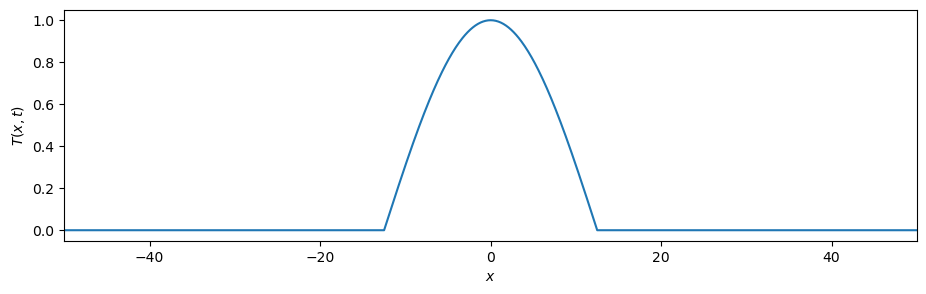

In [4]:
# Let's check with a plot of the ICs

plt.figure(figsize=(11, 3))

plt.plot(x, u_0.real)

plt.xlabel(r"$x$")
plt.ylabel(r"$T(x,t)$")

plt.xlim(-50., +50.)
plt.show()


## Fourier analysis:

### 4. Get the spatial frequencies for Fourier analysis:

In [5]:
# Wavenumbers = spatial frequencies:

k_numbers = 2*np.pi*np.fft.fftfreq(len(x), d = h)

#print(N, len(x))
#print(k_numbers.shape)

### 5. FFT the initial temperature profile:

In [6]:
# Fourier transform
u_0_fourier = np.fft.fft(u_0)

# Safe checks:
#print(u_0_fourier)
#print(u_0.shape, u_0_fourier.shape)

In [7]:
# Norm of Fourier transform

ampli_u_0_fourier = np.abs(u_0_fourier)/(u_0_fourier.size//2)

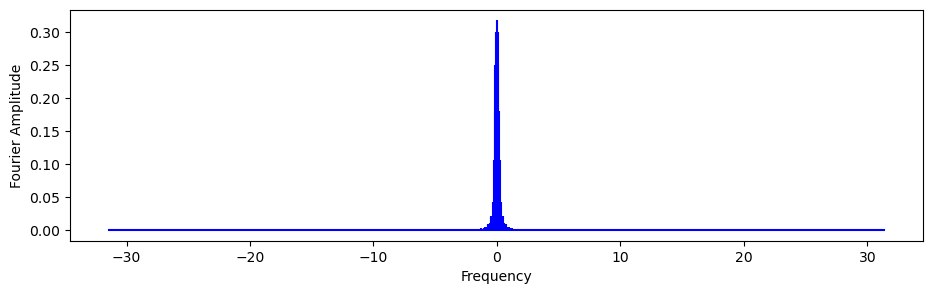

In [8]:
plt.figure(figsize = (11, 3))
plt.stem(k_numbers, ampli_u_0_fourier, 'b', markerfmt=" ", basefmt="-b")
plt.xlabel('Frequency')
plt.ylabel('Fourier Amplitude')

plt.show()

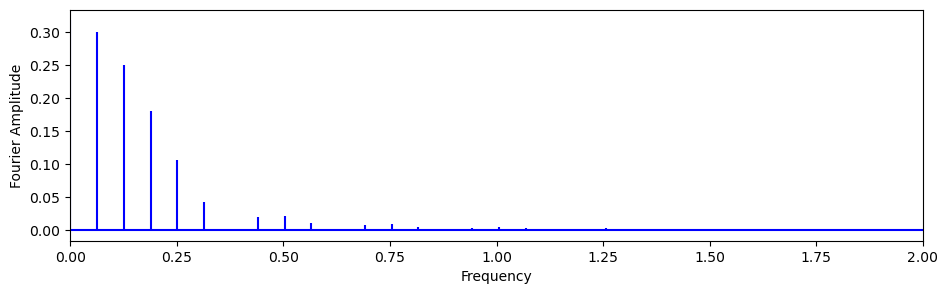

In [9]:
plt.figure(figsize = (11, 3))
plt.stem(k_numbers, ampli_u_0_fourier, 'b', markerfmt=" ", basefmt="-b")
plt.xlabel('Frequency')
plt.ylabel('Fourier Amplitude')
plt.xlim(0,2)
plt.show()

### 6. Concatenate real and complex numbers:


In [10]:
# Preliminary checks:
#print(u_0_fourier)

print(u_0_fourier[3])

print(u_0_fourier[3].real)
print(u_0_fourier[3].imag)


(-90.03311260689838-1.2047715046456398e-11j)
-90.03311260689838
-1.2047715046456398e-11


In [11]:
# IMPORTANT: we concatenate the real and imag #'s

u_0_fourier_conc = np.concatenate((u_0_fourier.real,u_0_fourier.imag))

#print(u_0_fourier_conc.shape)

#print(u_0_fourier_conc[3], u_0_fourier_conc[1003])

### 7. Time discretisation:

In [12]:
# Simulation time
b = 200.

# Time step
t_step = 1.

# Time axis:
t = np.arange(0., b, t_step)

#print(t.shape)

In [13]:
print(k_numbers.shape)

(1000,)


## Core of the FFT analysis:

### 8. Construct ODE (RHS of ODE)

In [14]:
# Function to get RHS

def rhs_ode(u_0_fourier_conc, t, k_numbers, c_2):
    """
    Function to calculate the slope of the k-ODEs in Fourier space.
    Inputs: concatenated array with Fourier #'s -> u_0_fourier_conc
            time axis -> t
            spatial freq/wavenumbers -> k_numbers
            dif. coef -> c_2
    """
    # Pasting both arrays back into a single one
    # Needed to input the ODE integrator later.
    u_tilde = u_0_fourier_conc[:N] + (1j)*u_0_fourier_conc[N:]
    
    # We compute the RHS
    rhs_u_tilde = -(c_2**2)*(k_numbers**2)*u_tilde
    
    # Write the output slopes for the integrator:
    rhs_ode = np.concatenate((rhs_u_tilde.real, rhs_u_tilde.imag))
    
    return rhs_ode

In [15]:
print(rhs_ode(u_0_fourier_conc, t, k_numbers, c_2).shape)

(2000,)


### 9. Integrating our k ODEs to find the solution for ${\hat u}= {\hat T}$

In [16]:
# We call odeint (allows to solve systems of ODEs)

solution = sint.odeint(rhs_ode, u_0_fourier_conc, t, args = (k_numbers, c_2))


print(solution.shape)

(200, 2000)


### 10. Reconstruct Complex solution:

This step gives us the solution in Fourier space.

In [17]:
# Combine the first N elements (Real) with the last N elements (Imag)
# In Fourier space
u_solution = solution[:, :N] + (1j)*solution[:, N:]

print(u_solution.shape)

(200, 1000)


### 11. Inverse Fourier transform of each u_solution

In [18]:
# Empty sln in real space:
inv_u_solution = np.zeros(u_solution.shape, dtype = complex)

print(inv_u_solution)

[[0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 ...
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]]


In [19]:
# For loop with 'n' as index

for n in range(len(t)):
    
    inv_u_solution[n, :] = np.fft.ifft(u_solution[n, :])
    

In [20]:
# Check the sln in real space

print(inv_u_solution)

[[ 5.68434189e-17-2.00686214e-30j -4.26325641e-17+4.32717988e-17j
   5.68434189e-17+2.87689116e-18j ...  8.52651283e-17-1.18912725e-17j
   0.00000000e+00+6.99743087e-18j  1.13686838e-16-1.93771301e-17j]
 [-1.37532652e-13+4.29474841e-19j  1.39735334e-13-2.03240337e-17j
  -1.37546863e-13-5.55015742e-20j ...  1.39692702e-13-4.75195110e-17j
  -1.37589495e-13-5.18664706e-18j  1.39806389e-13-1.55508114e-17j]
 [ 3.76971343e-13+2.15358972e-20j -3.74740239e-13-1.00531562e-17j
   3.77013976e-13+1.73450666e-18j ... -3.74797082e-13+3.81565869e-18j
   3.76928710e-13+2.09179027e-17j -3.74683395e-13-2.32312016e-17j]
 ...
 [ 3.22470768e-02+3.49082017e-20j  3.22489479e-02-3.85802530e-18j
   3.22545614e-02-2.77556337e-19j ...  3.22639172e-02-2.94011808e-19j
   3.22545614e-02+1.58478831e-17j  3.22489479e-02-3.73810693e-18j]
 [ 3.26215119e-02+3.37046881e-20j  3.26233850e-02+3.92741368e-18j
   3.26290046e-02-1.66533981e-19j ...  3.26383707e-02+6.82292681e-18j
   3.26290046e-02+9.77721929e-18j  3.26233850e-

### 12. Plotting the solution:

#### A. Temperature-position plot:

In [21]:
# Check tye BCs
print(inv_u_solution[79, -1])
print(inv_u_solution[99, -1])

(0.001091571318584414-6.985998822978471e-18j)
(0.0033542322403598917-9.299088101610383e-18j)


/opt/anaconda3/envs/py311/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/envs/py311/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


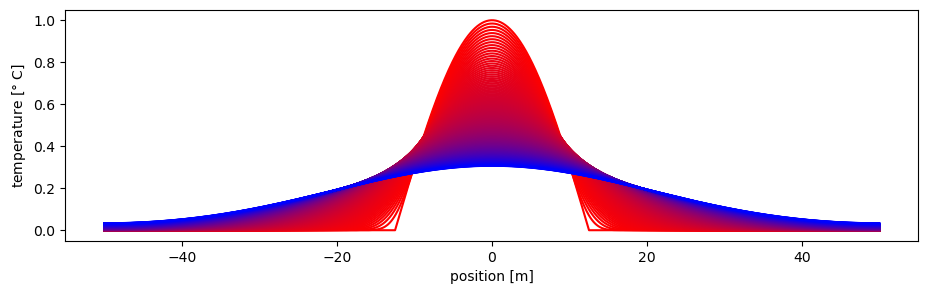

In [22]:
# Add colour

# Number of elements in the time axis:
m = len(t)

# Create our RGB scheme using 'm'
R = np.linspace(1, 0, m)
G = 0
B = np.linspace(0, 1, m)

# Fig. Environment:
plt.figure(figsize= (11, 3))

for j in range(m):
    plt.plot(x, inv_u_solution[j, :], color = [R[j], G, B[j]])

plt.xlabel("position [m]")
plt.ylabel("temperature [$\degree$ C]")

plt.show()

#### B. Surface plot in 3D:

In [23]:
from mpl_toolkits.mplot3d import axes3d

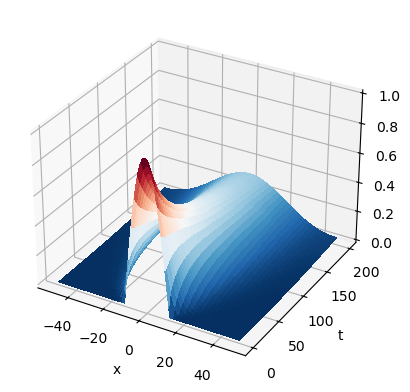

In [24]:
# Grid
x_grid, t_grid = np.meshgrid(x, t)

# Plot
fig = plt.figure()

ax = plt.axes(projection='3d')
#ax.contour3D(x_grid, t_grid, u, 1000, cmap='viridis')
# Creates 'n=10' contours at different Z to make the surface

ax.plot_surface(x_grid, t_grid, inv_u_solution.real, cmap='RdBu_r', linewidth=0, antialiased=False)

ax.set_xlabel('x')  # Customised labels for axes
ax.set_ylabel('t')
ax.set_zlabel('T')

plt.show()

#### C. 2D projection of the surface onto the x vs. t plane

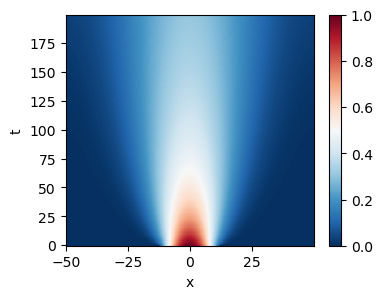

In [25]:
plt.figure(figsize= (4, 3))

#ax = plt.axes(projection='3d')
#ax.contour3D(x_grid, t_grid, u, 1000, cmap='viridis') # Creates 'n=10' contours at different Z to make the surface

z_temp = plt.pcolor(x_grid, t_grid, inv_u_solution.real, cmap='RdBu_r')

plt.colorbar(z_temp)

plt.xlabel('x')
plt.ylabel('t')
#plt.zlabel('T')

plt.show()